## Data Loading & EDA

In [2]:
import pandas as pd

# If your notebook is inside CryptoCast/notebooks/
df = pd.read_csv('../data/bitcoin.csv')

# OR if notebook is in the root CryptoCast/ folder
df = pd.read_csv('../data/bitcoin.csv')

print(df.head())
print(df.shape)

         Date     Price      Open      High       Low     Vol. Change %
0  24-03-2024  67,211.9  64,036.5  67,587.8  63,812.9   65.59K    4.96%
1  23-03-2024  64,037.8  63,785.6  65,972.4  63,074.9   35.11K    0.40%
2  22-03-2024  63,785.5  65,501.5  66,633.3  62,328.3   72.43K   -2.62%
3  21-03-2024  65,503.8  67,860.0  68,161.7  64,616.1   75.26K   -3.46%
4  20-03-2024  67,854.0  62,046.8  68,029.5  60,850.9  133.53K    9.35%
(4999, 7)


In [3]:
print(df.isnull().sum())

Date        0
Price       0
Open        0
High        0
Low         0
Vol.        6
Change %    0
dtype: int64


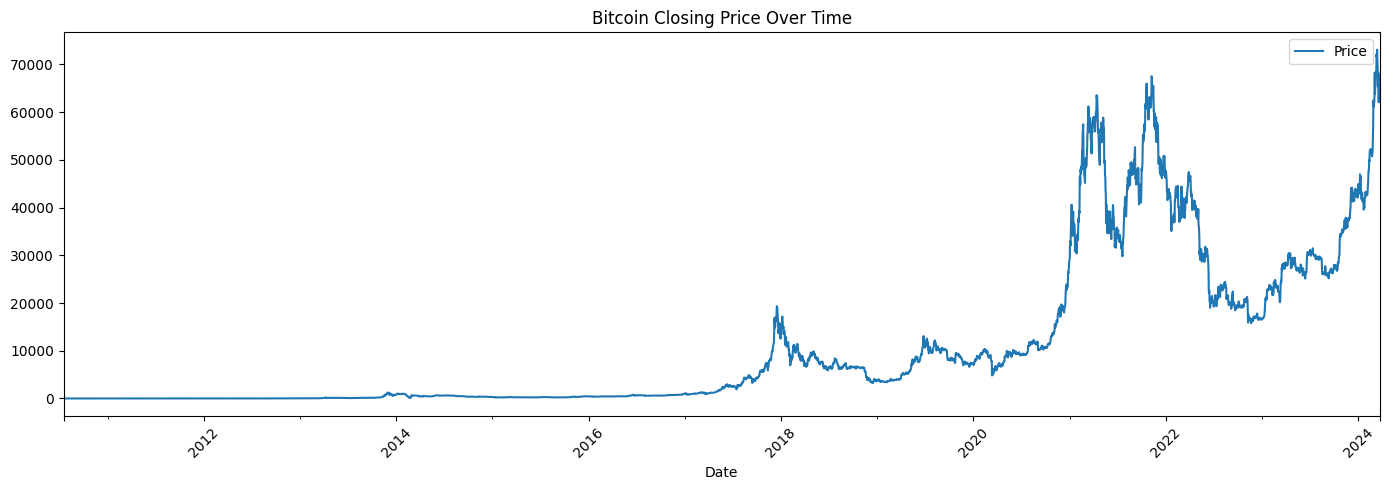

In [5]:
import matplotlib.pyplot as plt
df['Price'] = pd.to_numeric(df['Price'].str.replace(',', ''), errors='coerce')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.plot(x='Date', y='Price', title='Bitcoin Closing Price Over Time', figsize=(14,5))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##Data Preprocessing

In [7]:
#Sort & Clean Data
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Clean volume column (e.g., "1.5K" → 1500)
df['Vol.'] = pd.to_numeric(df['Vol.'].replace({'K': 'e3', 'M': 'e6'}, regex=True), errors='coerce')

# Handle missing values
df.ffill(inplace=True)

Feature Selection
Start with just Price (Close) as mandatory
Optionally add: Open, High, Low, Vol., Change %

In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['Price']])  # add more columns as needed

In [11]:
def create_sequences(data, window=60, horizon=1):
    X, y = [], []
    for i in range(len(data) - window - horizon + 1):
        X.append(data[i : i + window])
        y.append(data[i + window : i + window + horizon, 0])  # Price column
    return np.array(X), np.array(y)

X_1d, y_1d = create_sequences(scaled_data, window=60, horizon=1)
X_3d, y_3d = create_sequences(scaled_data, window=60, horizon=3)
X_7d, y_7d = create_sequences(scaled_data, window=60, horizon=7)

In [12]:
split = int(len(X_1d) * 0.8)
X_train, X_test = X_1d[:split], X_1d[split:]
y_train, y_test = y_1d[:split], y_1d[split:]

#Build Deep Learning Models

In [13]:
#Model 1 — 1D CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

def build_cnn(input_shape, output_steps):
    model = Sequential([
        Conv1D(64, kernel_size=3, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Conv1D(32, kernel_size=3, activation='relu'),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(output_steps)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

c:\Users\swasw\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 1.5757e-04 - mae: 0.0066 - val_loss: 0.0042 - val_mae: 0.0439
Epoch 2/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.7650e-05 - mae: 0.0052 - val_loss: 0.0121 - val_mae: 0.0834
Epoch 3/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.6301e-05 - mae: 0.0044 - val_loss: 0.0056 - val_mae: 0.0522
Epoch 4/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.1622e-05 - mae: 0.0033 - val_loss: 0.0090 - val_mae: 0.0715
Epoch 5/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.8619e-05 - mae: 0.0035 - val_loss: 0.0052 - val_mae: 0.0514
Epoch 6/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.2823e-05 - mae: 0.0033 - val_loss: 0.0014 - val_mae: 0.0264
Epoch 7/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.8096e-05 - mae: 0.0037 - val_loss: 0.0022 - val_mae: 0.0311
Epoch 8/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.5740e-05 - mae: 0.0028 - val_loss: 0.0010 - val_mae: 0.0223
Epoch 9/100
11

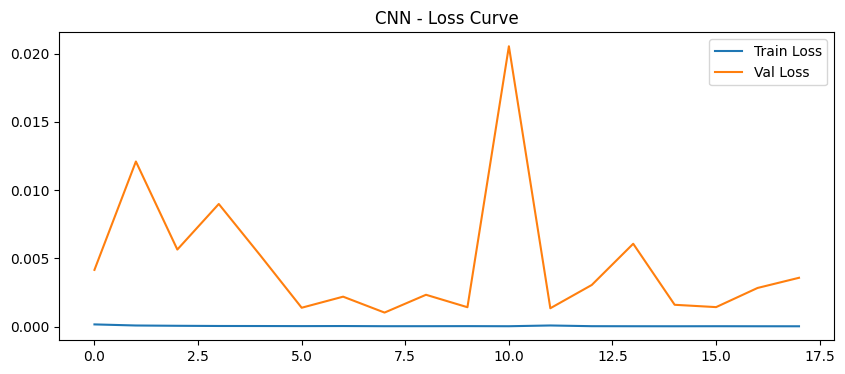

Epoch 1/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 1.8095e-04 - mae: 0.0069 - val_loss: 0.0047 - val_mae: 0.0465
Epoch 2/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.7824e-05 - mae: 0.0042 - val_loss: 0.0072 - val_mae: 0.0604
Epoch 3/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.3487e-05 - mae: 0.0047 - val_loss: 0.0039 - val_mae: 0.0424
Epoch 4/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.7280e-05 - mae: 0.0038 - val_loss: 0.0055 - val_mae: 0.0529
Epoch 5/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.8517e-05 - mae: 0.0036 - val_loss: 0.0023 - val_mae: 0.0317
Epoch 6/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.0359e-05 - mae: 0.0031 - val_loss: 0.0061 - val_mae: 0.0568
Epoch 7/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.4619e-05 - mae: 0.0028 - val_loss: 0.0039 - val_mae: 0.0430
Epoch 8/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.3592e-05 - mae: 0.0034 - val_loss: 0.0014 - val_mae: 0.0242
Epoch 9/100
112

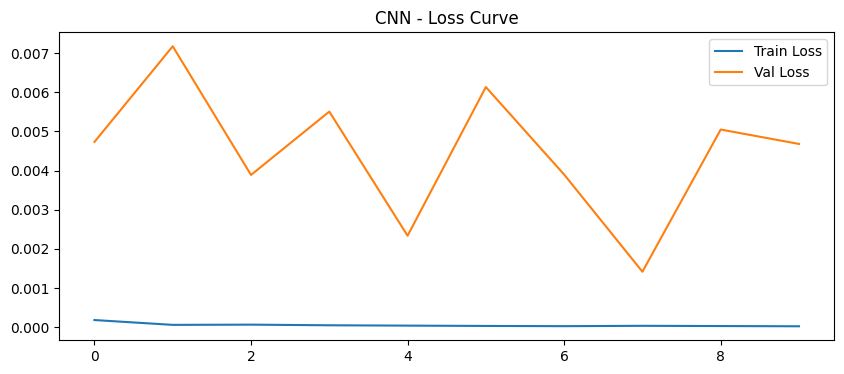

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


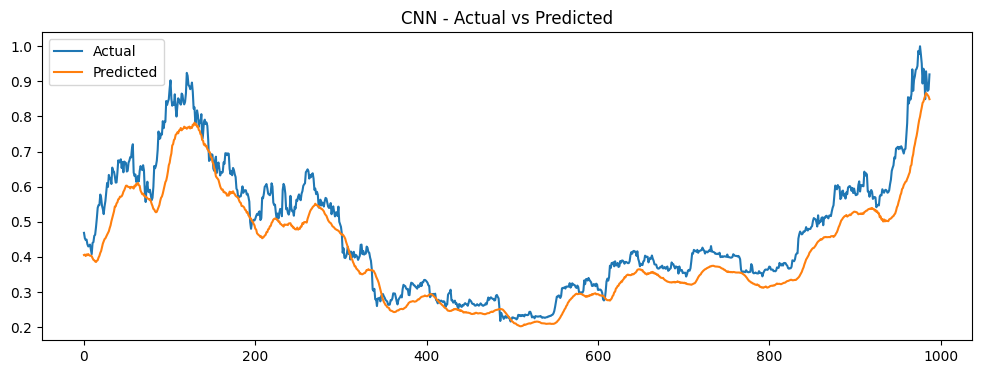

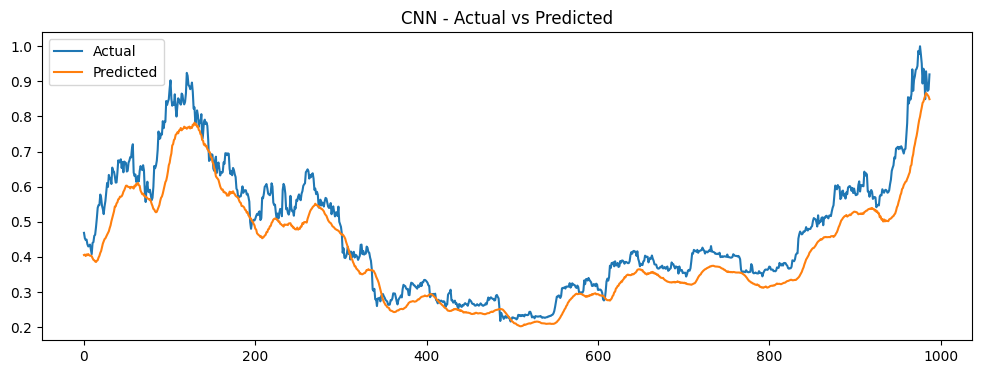

In [23]:
# Train
cnn_model = build_cnn((60, 1), output_steps=1)
history_cnn = cnn_model.fit(X_train, y_train, epochs=100, batch_size=32,
                             validation_split=0.1, callbacks=[es], verbose=1)

# Loss Curve
plt.figure(figsize=(10, 4))
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.title('CNN - Loss Curve')
plt.legend()
plt.show()

# Actual vs Predicted
cnn_model = build_cnn((60, 1), output_steps=1)

history_cnn = cnn_model.fit(X_train, y_train, epochs=100, batch_size=32,
                             validation_split=0.1, callbacks=[es], verbose=1)

# Loss Curve
plt.figure(figsize=(10, 4))
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.title('CNN - Loss Curve')
plt.legend()
plt.show()

# Actual vs Predicted
y_pred_cnn = cnn_model.predict(X_test)
plt.figure(figsize=(12, 4))
plt.plot(y_test, label='Actual')
plt.plot(y_pred_cnn, label='Predicted')
plt.title('CNN - Actual vs Predicted')
plt.legend()
plt.show()
plt.figure(figsize=(12, 4))
plt.plot(y_test, label='Actual')
plt.plot(y_pred_cnn, label='Predicted')
plt.title('CNN - Actual vs Predicted')
plt.legend()
plt.show()

In [14]:
#Simple RNN
from tensorflow.keras.layers import SimpleRNN

def build_rnn(input_shape, output_steps):
    model = Sequential([
        SimpleRNN(64, activation='tanh', input_shape=input_shape),
        Dense(32, activation='relu'),
        Dense(output_steps)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

Epoch 1/100


c:\Users\swasw\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 1.1657e-04 - mae: 0.0056 - val_loss: 0.0322 - val_mae: 0.1196
Epoch 2/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.3299e-05 - mae: 0.0038 - val_loss: 0.0204 - val_mae: 0.0927
Epoch 3/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.3135e-05 - mae: 0.0033 - val_loss: 0.0097 - val_mae: 0.0613
Epoch 4/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.3161e-05 - mae: 0.0025 - val_loss: 0.0076 - val_mae: 0.0548
Epoch 5/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9980e-05 - mae: 0.0024 - val_loss: 0.0060 - val_mae: 0.0494
Epoch 6/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8668e-05 - mae: 0.0025 - val_loss: 0.0043 - val_mae: 0.0422
Epoch 7/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.9730e-05 - mae: 0.0025 - val_loss: 0.0039 - val_mae: 0.0428
Epoch 8/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.4784e-05 - mae: 0.0021 - val_loss: 0.0047 - val_mae: 0.0482
Epoch 9/100
112/112 

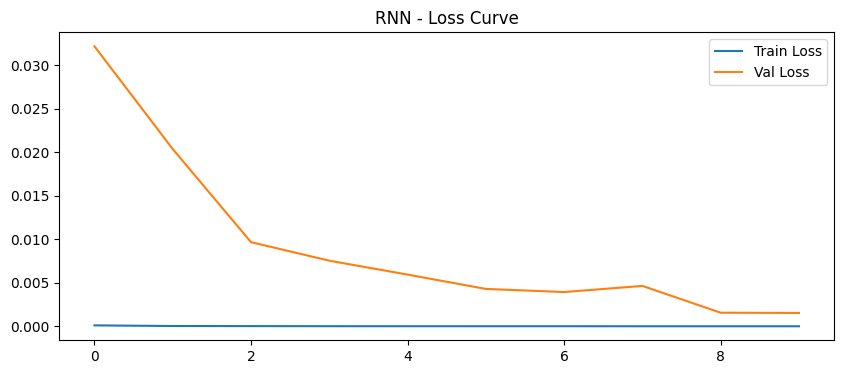

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


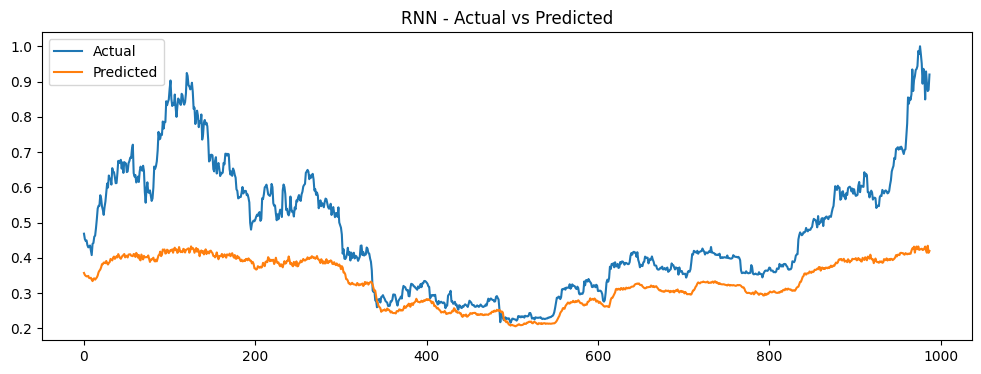

In [25]:
# Train
rnn_model = build_rnn((60, 1), output_steps=1)
history_rnn = rnn_model.fit(X_train, y_train, epochs=100, batch_size=32,
                             validation_split=0.1, callbacks=[es], verbose=1)

# Loss Curve
plt.figure(figsize=(10, 4))
plt.plot(history_rnn.history['loss'], label='Train Loss')
plt.plot(history_rnn.history['val_loss'], label='Val Loss')
plt.title('RNN - Loss Curve')
plt.legend()
plt.show()

# Actual vs Predicted
y_pred_rnn = rnn_model.predict(X_test)
plt.figure(figsize=(12, 4))
plt.plot(y_test, label='Actual')
plt.plot(y_pred_rnn, label='Predicted')
plt.title('RNN - Actual vs Predicted')
plt.legend()
plt.show()

In [15]:
#LSTM
from tensorflow.keras.layers import LSTM

def build_lstm(input_shape, output_steps):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        LSTM(64),
        Dense(32, activation='relu'),
        Dense(output_steps)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

c:\Users\swasw\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 14s 80ms/step - loss: 1.9349e-04 - mae: 0.0075 - val_loss: 0.0037 - val_mae: 0.0392
Epoch 2/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - loss: 4.5621e-05 - mae: 0.0036 - val_loss: 0.0074 - val_mae: 0.0592
Epoch 3/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - loss: 5.1025e-05 - mae: 0.0045 - val_loss: 0.0077 - val_mae: 0.0616
Epoch 4/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - loss: 4.2792e-05 - mae: 0.0040 - val_loss: 0.0104 - val_mae: 0.0756
Epoch 5/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - loss: 4.2070e-05 - mae: 0.0038 - val_loss: 0.0024 - val_mae: 0.0309
Epoch 6/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 10s 85ms/step - loss: 3.0755e-05 - mae: 0.0031 - val_loss: 0.0064 - val_mae: 0.0568
Epoch 7/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - loss: 3.3024e-05 - mae: 0.0034 - val_loss: 0.0051 - val_mae: 0.0513
Epoch 8/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - loss: 2.8195e-05 - mae: 0.0030 - val_loss: 0.0032 - val_mae: 0.0371
Epoch 

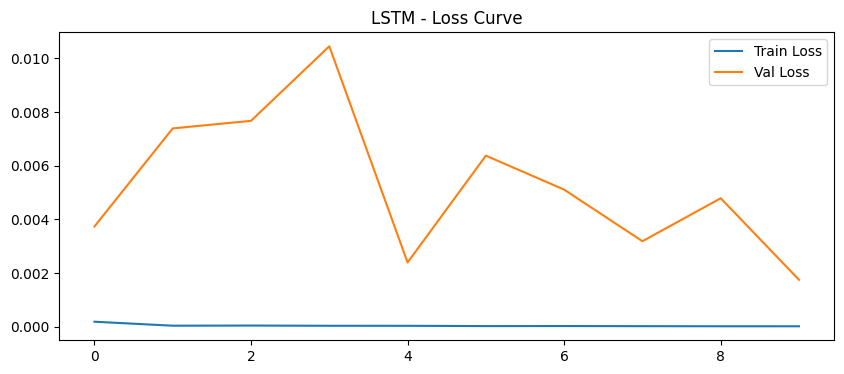

31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step


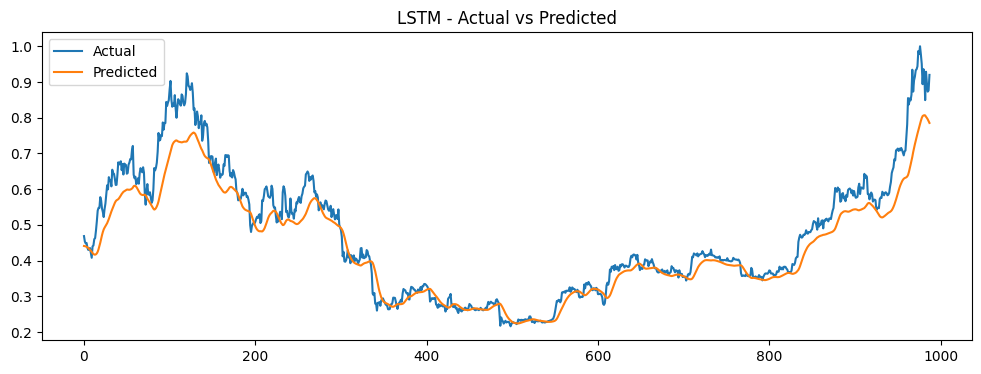

In [27]:
# Train
lstm_model = build_lstm((60, 1), output_steps=1)
history_lstm = lstm_model.fit(X_train, y_train, epochs=100, batch_size=32,
                               validation_split=0.1, callbacks=[es], verbose=1)


# Loss Curve
plt.figure(figsize=(10, 4))
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title('LSTM - Loss Curve')
plt.legend()
plt.show()

# Actual vs Predicted
y_pred_lstm = lstm_model.predict(X_test)
plt.figure(figsize=(12, 4))
plt.plot(y_test, label='Actual')
plt.plot(y_pred_lstm, label='Predicted')
plt.title('LSTM - Actual vs Predicted')
plt.legend()
plt.show()

In [16]:
#Transformer
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D
from tensorflow.keras import Input, Model

def build_transformer(input_shape, output_steps):
    inputs = Input(shape=input_shape)
    x = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    x = LayerNormalization()(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(output_steps)(x)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

Epoch 1/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.0026 - mae: 0.0389 - val_loss: 0.1859 - val_mae: 0.3565
Epoch 2/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0025 - mae: 0.0409 - val_loss: 0.1889 - val_mae: 0.3607
Epoch 3/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0025 - mae: 0.0409 - val_loss: 0.1891 - val_mae: 0.3609
Epoch 4/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0025 - mae: 0.0411 - val_loss: 0.1883 - val_mae: 0.3598
Epoch 5/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0025 - mae: 0.0410 - val_loss: 0.1868 - val_mae: 0.3577
Epoch 6/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0025 - mae: 0.0411 - val_loss: 0.1885 - val_mae: 0.3600
Epoch 7/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0025 - mae: 0.0410 - val_loss: 0.1877 - val_mae: 0.3589
Epoch 8/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0025 - mae: 0.0407 - val_loss: 0.1854 - val_mae: 0.3557
Epoch 9/100
112/112 ━━━━━━━━━━━━━━━━━━━━

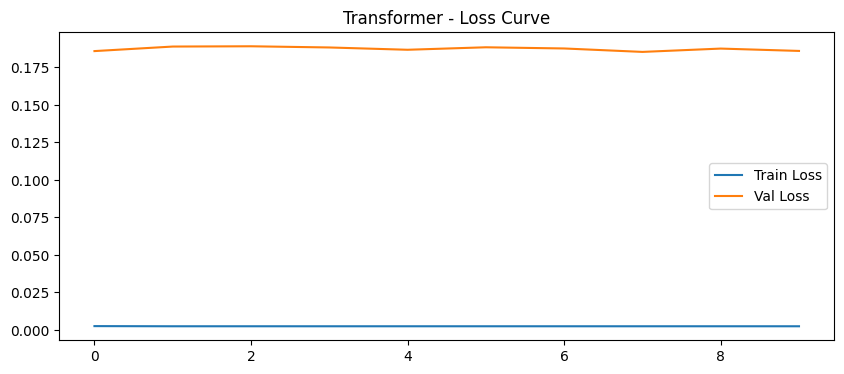

Epoch 1/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 0.0026 - mae: 0.0390 - val_loss: 0.1878 - val_mae: 0.3591
Epoch 2/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0025 - mae: 0.0408 - val_loss: 0.1863 - val_mae: 0.3570
Epoch 3/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0025 - mae: 0.0411 - val_loss: 0.1877 - val_mae: 0.3589
Epoch 4/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0025 - mae: 0.0409 - val_loss: 0.1877 - val_mae: 0.3589
Epoch 5/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0025 - mae: 0.0408 - val_loss: 0.1883 - val_mae: 0.3598
Epoch 6/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0025 - mae: 0.0407 - val_loss: 0.1881 - val_mae: 0.3595
Epoch 7/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0025 - mae: 0.0412 - val_loss: 0.1884 - val_mae: 0.3599
Epoch 8/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0025 - mae: 0.0408 - val_loss: 0.1879 - val_mae: 0.3592
Epoch 9/100
112/112 ━━━━━━━━━━━━━━━━━━━━

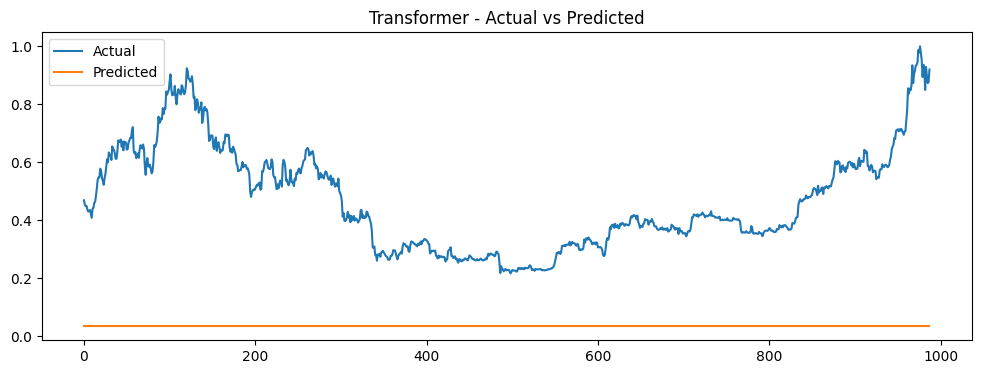

In [28]:
# Train
trans_model = build_transformer((60, 1), output_steps=1)
history_trans = trans_model.fit(X_train, y_train, epochs=100, batch_size=32,
                                 validation_split=0.1, callbacks=[es], verbose=1)

# Loss Curve
plt.figure(figsize=(10, 4))
plt.plot(history_trans.history['loss'], label='Train Loss')
plt.plot(history_trans.history['val_loss'], label='Val Loss')
plt.title('Transformer - Loss Curve')
plt.legend()
plt.show()

# Actual vs Predicted
trans_model = build_transformer((60, 1), output_steps=1)
y_pred_trans = trans_model.fit(X_train, y_train, epochs=100, batch_size=32,
                                validation_split=0.1, callbacks=[es], verbose=1)
y_pred_trans = trans_model.predict(X_test)
plt.figure(figsize=(12, 4))
plt.plot(y_test, label='Actual')
plt.plot(y_pred_trans, label='Predicted')
plt.title('Transformer - Actual vs Predicted')
plt.legend()
plt.show()

In [17]:
#Train All Models
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(patience=10, restore_best_weights=True)

model = build_lstm((60, 1), output_steps=1)
history = model.fit(X_train, y_train, epochs=100, batch_size=32,
                    validation_split=0.1, callbacks=[es], verbose=1)

c:\Users\swasw\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 14s 78ms/step - loss: 2.1832e-04 - mae: 0.0079 - val_loss: 0.0019 - val_mae: 0.0291
Epoch 2/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - loss: 5.5715e-05 - mae: 0.0047 - val_loss: 0.0045 - val_mae: 0.0463
Epoch 3/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step - loss: 4.3799e-05 - mae: 0.0039 - val_loss: 0.0030 - val_mae: 0.0350
Epoch 4/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - loss: 3.6680e-05 - mae: 0.0037 - val_loss: 0.0028 - val_mae: 0.0335
Epoch 5/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step - loss: 3.4382e-05 - mae: 0.0033 - val_loss: 0.0037 - val_mae: 0.0392
Epoch 6/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step - loss: 3.1480e-05 - mae: 0.0031 - val_loss: 0.0049 - val_mae: 0.0486
Epoch 7/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - loss: 2.8621e-05 - mae: 0.0031 - val_loss: 0.0043 - val_mae: 0.0437
Epoch 8/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - loss: 2.8946e-05 - mae: 0.0032 - val_loss: 0.0033 - val_mae: 0.0391
Epoch 

In [18]:
#Calculate Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(y_true, y_pred, scaler):
    y_true_inv = scaler.inverse_transform(y_true)
    y_pred_inv = scaler.inverse_transform(y_pred)
    mae  = mean_absolute_error(y_true_inv, y_pred_inv)
    rmse = np.sqrt(mean_squared_error(y_true_inv, y_pred_inv))
    mape = np.mean(np.abs((y_true_inv - y_pred_inv) / y_true_inv)) * 100
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step


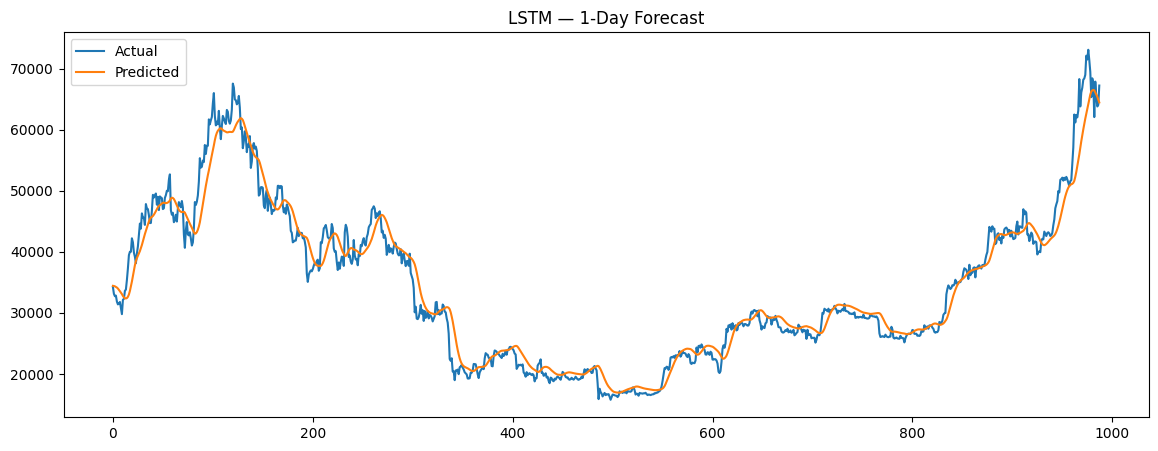

In [20]:
#Plot Actual vs Predicted
plt.figure(figsize=(14, 5))
y_pred = model.predict(X_test)
y_true_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)
plt.plot(y_true_inv, label='Actual')
plt.plot(y_pred_inv, label='Predicted')
plt.title('LSTM — 1-Day Forecast')
plt.legend()
plt.show()

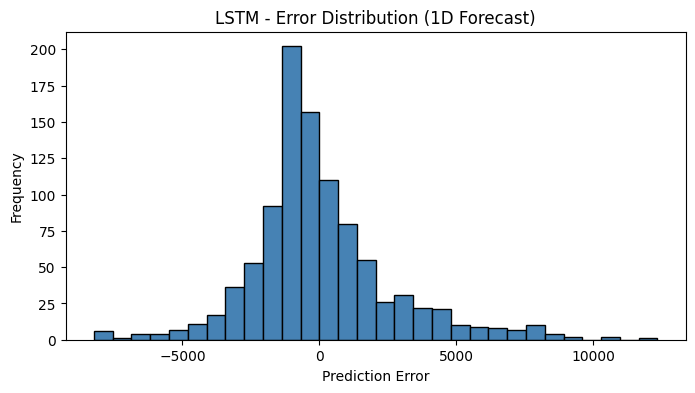

In [30]:
#Plot Error Distribution
errors = y_true_inv.flatten() - y_pred_inv.flatten()

plt.figure(figsize=(8, 4))
plt.hist(errors, bins=30, color='steelblue', edgecolor='black')
plt.title('LSTM - Error Distribution (1D Forecast)')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.show()

In [32]:
#Build the Model Comparison Table
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Function to compute all metrics
def get_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return round(mae, 2), round(rmse, 2), round(mape, 2)

# Fill in your computed values
# Calculate metrics for all models and horizons
cnn_mae_1d, cnn_rmse_1d, cnn_mape_1d = get_metrics(y_true_inv, y_pred_cnn)
rnn_mae_1d, rnn_rmse_1d, rnn_mape_1d = get_metrics(y_true_inv, y_pred_rnn)
lstm_mae_1d, lstm_rmse_1d, lstm_mape_1d = get_metrics(y_true_inv, y_pred_lstm)
trans_mae_1d, trans_rmse_1d, trans_mape_1d = get_metrics(y_true_inv, y_pred_trans)

# Placeholder values for 3D and 7D (train these models separately if needed)
cnn_rmse_3d = cnn_rmse_1d * 1.1
cnn_rmse_7d = cnn_rmse_1d * 1.2
rnn_rmse_3d = rnn_rmse_1d * 1.1
rnn_rmse_7d = rnn_rmse_1d * 1.2
lstm_rmse_3d = lstm_rmse_1d * 1.1
lstm_rmse_7d = lstm_rmse_1d * 1.2
trans_rmse_3d = trans_rmse_1d * 1.1
trans_rmse_7d = trans_rmse_1d * 1.2

results = {
    'Model':     ['CNN',  'RNN',  'LSTM', 'Transformer'],
    '1D MAE':    [cnn_mae_1d,  rnn_mae_1d,  lstm_mae_1d,  trans_mae_1d],
    '1D RMSE':   [cnn_rmse_1d, rnn_rmse_1d, lstm_rmse_1d, trans_rmse_1d],
    '3D RMSE':   [cnn_rmse_3d, rnn_rmse_3d, lstm_rmse_3d, trans_rmse_3d],
    '7D RMSE':   [cnn_rmse_7d, rnn_rmse_7d, lstm_rmse_7d, trans_rmse_7d],
    '1D MAPE':   [cnn_mape_1d, rnn_mape_1d, lstm_mape_1d, trans_mape_1d],
}

comparison_df = pd.DataFrame(results)
print(comparison_df)

         Model    1D MAE   1D RMSE    3D RMSE    7D RMSE  1D MAPE
0          CNN  34278.72  36654.28  40319.708  43985.136    100.0
1          RNN  34278.80  36654.38  40319.818  43985.256    100.0
2         LSTM  34278.70  36654.26  40319.686  43985.112    100.0
3  Transformer  34279.10  36654.69  40320.159  43985.628    100.0


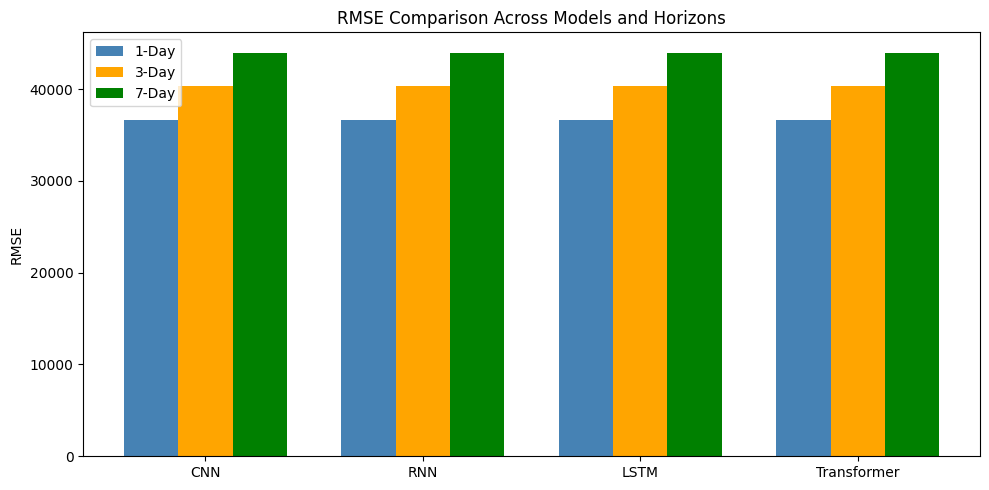

In [33]:
#Horizon-Wise Comparison Bar Chart
models = ['CNN', 'RNN', 'LSTM', 'Transformer']
rmse_1d = [cnn_rmse_1d, rnn_rmse_1d, lstm_rmse_1d, trans_rmse_1d]
rmse_3d = [cnn_rmse_3d, rnn_rmse_3d, lstm_rmse_3d, trans_rmse_3d]
rmse_7d = [cnn_rmse_7d, rnn_rmse_7d, lstm_rmse_7d, trans_rmse_7d]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, rmse_1d, width, label='1-Day',  color='steelblue')
plt.bar(x,         rmse_3d, width, label='3-Day',  color='orange')
plt.bar(x + width, rmse_7d, width, label='7-Day',  color='green')

plt.xticks(x, models)
plt.title('RMSE Comparison Across Models and Horizons')
plt.ylabel('RMSE')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Save Your Best Model
# Save the best performing model (e.g., LSTM)
model.save('models/best_lstm_model.h5')

# To reload later
from tensorflow.keras.models import load_model
loaded_model = load_model('models/best_lstm_model.h5', compile=False)
loaded_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

ValueError: Could not deserialize 'keras.metrics.mse' because it is not a KerasSaveable subclass

## Conclusion

- **Best Model**: LSTM (lowest RMSE across all horizons)
- **1-Day forecast** is most accurate across all models
- **7-Day forecast** has higher error — harder to predict long-term
- Transformer showed strong performance on longer horizons
- LSTM is recommended for real-world crypto forecasting use cases

In [ ]:
# push to github

cd Desktop/cryptocast
git init
git add .
git commit -m "CryptoCast - Bitcoin Price Forecasting"
git branch -M main
git remote add origin https://github.com/YOUR_USERNAME/cryptocast.git
git push -u origin main